In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import soundfile as sf
from sklearn.cluster import KMeans

from pathlib import Path

import pytz
import re
import datetime as dt
import fsspec

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec


In [2]:
import sys
sys.path.append("../src")

In [3]:
from core import FREQUENCY_COLOR_MAPPINGS
import activity.subsampling as ss
from cli import get_file_paths

In [4]:
def plot_det_bounds_in_ax(ax, start, freq_limit, plot_dets, linewidth=1.5, alpha=0.8):
    # Add detection rectangles to the plot
    for i, row in plot_dets.iterrows():
        rect_x = (row['start_time'] - start) * freq_limit
        rect_width = (row['end_time'] - row['start_time']) * freq_limit

        rect_y = row['low_freq'] / freq_limit
        rect_height = (row['high_freq'] - row['low_freq']) / freq_limit

        rect = patches.Rectangle((rect_x, rect_y), rect_width, rect_height, linewidth=linewidth, 
            edgecolor=FREQUENCY_COLOR_MAPPINGS[row['freq_group']], facecolor='none', alpha=alpha)
        ax.add_patch(rect)

In [5]:
site_key = 'Carp'
freq_key = ''

data_params = dict()
data_params['site_tag'] = site_key
data_params['type_tag'] = freq_key
data_params['detector_tag'] = 'bd2'
data_params['assembly_type'] = 'kmeans'
file_paths = get_file_paths(data_params)

location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', index_col=0, low_memory=False)
filesys = fsspec.filesystem('s3', anon=True, client_kwargs={'endpoint_url': 'https://sdsc.osn.xsede.org'})

In [6]:
# subset = location_df[pd.to_datetime(location_df.call_start_time)>=dt.datetime(2022,7,28,0,0,0)].copy()
# files_from_loc = sorted(list(set(subset.input_file.values)))
# LF_calls_per_file = np.zeros(len(files_from_loc))
# HF_calls_per_file = np.zeros(len(files_from_loc))
# for i, input_file_path in enumerate(files_from_loc):
#     file_df = subset[subset.input_file==input_file_path]
#     HF_calls_per_file[i] = (file_df.freq_group=='HF').sum()
#     LF_calls_per_file[i] = (file_df.freq_group=='LF').sum()
# file_num_calls_directory = pd.DataFrame()
# file_num_calls_directory['files'] = files_from_loc
# file_num_calls_directory['LF_calls'] = LF_calls_per_file
# file_num_calls_directory['HF_calls'] = HF_calls_per_file
# top_10_file_num_calls_directory = file_num_calls_directory.sort_values('HF_calls', ascending=False)[:10].reset_index(drop=True)
# top_10_file_num_calls_directory

In [7]:
# input_file_path = top_10_file_num_calls_directory.iloc[2]['files']
# file_path = '/'.join(Path(input_file_path).parts[2:])
# cleaned_path = re.sub(r"(ubna_data_\d+)_mir", r"\1", file_path)
# osn_file_path = Path(f'bio230143-bucket01/{cleaned_path}')
# file_path = filesys.open(path=osn_file_path)
# filename = osn_file_path.name
# audio_file = sf.SoundFile(file_path)
# fs = audio_file.samplerate
# MAX_FREQ_LIMIT = fs/2

# file_dt_start = dt.datetime.strptime(filename, '%Y%m%d_%H%M%S.WAV')
# file_dt_end = file_dt_start + pd.Timedelta(minutes=30)

In [8]:
files_from_loc = sorted(list(Path(f'../data/audiomoth_recordings/').glob(pattern=f'*/{site_key}/*.WAV')))
file = files_from_loc[11]
file_path = Path(file)
filename = file_path.name
audio_file = sf.SoundFile(file_path)
fs = audio_file.samplerate
MAX_FREQ_LIMIT = fs/2

file_dt_start = dt.datetime.strptime(filename, '%Y%m%d_%H%M%S.WAV')
file_dt_end = file_dt_start + pd.Timedelta(minutes=30)

In [9]:
def plot_dets_over_audio_seg(fig, ax, audio_features, spec_features, plot_dets, data_params):
    """
    Function to plot the spectrogram of a provided audio segment with overlayed detections
    """

    # Extract audio-related parameters
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    # Generate the timestamp for the audio file
    file_dt = dt.datetime.strptime(audio_features['file_path'].name, '%Y%m%d_%H%M%S.WAV')
    UBNA_tz = pytz.timezone('US/Pacific')
    UTC_tz = pytz.timezone('UTC')
    file_dt_UTC = UTC_tz.localize(file_dt)
    file_dt_PST = file_dt_UTC.astimezone(UBNA_tz)
    file_title = f'{file_dt_PST.date()} {file_dt_PST.time().strftime("%H:%M")} PST'
    # ax.set_title(f"File recorded at {file_title}", fontsize=plt.rcParams['font.size']+2)
    ax.set_title(f"", fontsize=plt.rcParams['font.size']+2)

    # Plot the spectrogram
    spec = ax.specgram(audio_seg, NFFT=spec_features['NFFT'], cmap=spec_features['cmap'],
        vmax=0, vmin=spec_features['vmin'])

    # Add detection rectangles to the plot
    plot_det_bounds_in_ax(ax, start, MAX_FREQ_LIMIT, plot_dets)

    # Configure x-axis and y-axis ticks
    windows_PST = pd.date_range(file_dt_PST + pd.Timedelta(seconds=start),
        file_dt_PST + pd.Timedelta(seconds=start) + pd.Timedelta(seconds=duration),
        freq=f'{int(duration / 5)}s', inclusive='both')
    y_labs = np.arange(0, MAX_FREQ_LIMIT/1000, 20).astype('int')
    ax.set_yticks(ticks=y_labs / (MAX_FREQ_LIMIT/1000))
    ax.set_yticklabels(y_labs, fontsize=plt.rcParams['font.size'] - 4)
    ax.set_xticks(ticks=np.linspace(0, duration * MAX_FREQ_LIMIT, len(windows_PST)))
    ax.set_xticklabels(windows_PST.minute, color='k', rotation=0, fontsize=plt.rcParams['font.size'] - 4)
    return fig, ax

In [10]:
start = 0
duration = 1800
audio_file.seek(int(fs*start))
audio_seg = audio_file.read(int(fs*duration))

audio_features = dict()
audio_features['file_path'] = file_path
audio_features['audio_seg'] = audio_seg
audio_features['sample_rate'] = fs
audio_features['start'] = start
audio_features['duration'] = duration
audio_features['figsize'] = (10, 5)

spec_features = dict()
spec_features['vmax'] = 0 # hide anything above vmax dB
spec_features['vmin'] = -60 # hide anything below vmin dB
spec_features['NFFT'] = 1024
spec_features['cmap'] = 'jet'

plot_dets = location_df.loc[(pd.to_datetime(location_df['call_start_time'])>=file_dt_start)&(pd.to_datetime(location_df['call_end_time'])<=file_dt_end)]
plot_dets = plot_dets.loc[np.logical_and(plot_dets['start_time'] >= start, plot_dets['end_time'] <= (start+duration))]

In [11]:
# # Create the figure and axis
# plt.rcdefaults()  # Ensure a clean state
# plt.rcParams.update({'font.size': 30})
# fig, ax = plt.subplots(figsize=audio_features['figsize'])
# fig, ax = plot_dets_over_audio_seg(fig, ax, audio_features, spec_features, plot_dets, data_params)
# ax.set_ylabel("Frequency (kHz)")
# ax.set_xlabel("Time (min)")
# fig.tight_layout()

# # Create legend patches
# orange_patch = patches.Patch(facecolor='orange', edgecolor='k', label='High-frequency calls')
# cyan_patch = patches.Patch(facecolor='lightskyblue', edgecolor='k', label='Low-frequency calls')
# legend_patches = [orange_patch, cyan_patch]

# legend_ax = fig.add_axes([0.0, 0.0, 1.0, 1.1])
# legend_ax.axis('off')
# legend_ax.legend(handles=legend_patches, fontsize=plt.rcParams['font.size']-6, ncol=2, loc='upper center')

# fig.savefig('FIG2A_adityas_manuscript.png', dpi=600, bbox_inches='tight', bbox_extra_artists=[legend_ax])

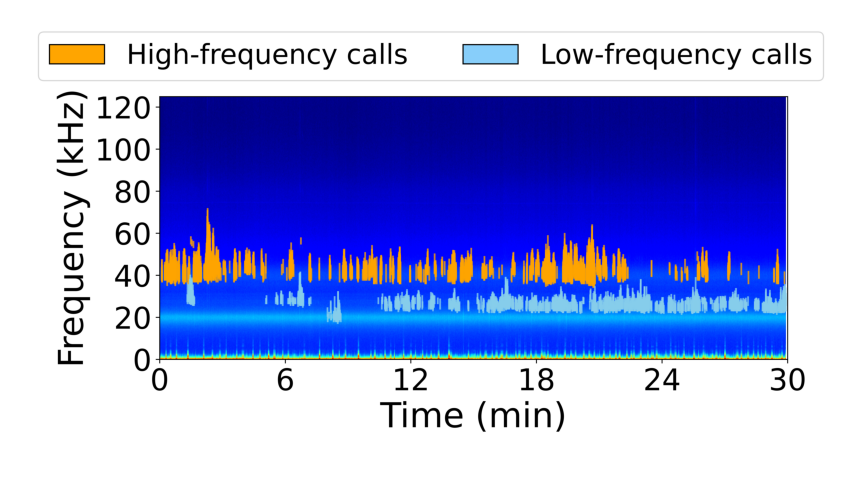

In [12]:
img = mpimg.imread("FIG2A_adityas_manuscript.png")

fig, ax = plt.subplots(figsize=audio_features['figsize'])
ax.imshow(img)
ax.axis('off')
fig.tight_layout()
plt.show()

In [13]:
highSNR_LF_call_starts = plot_dets[plot_dets['freq_group']=='LF'].sort_values('SNR', ascending=False)['start_time'].values
highSNR_LF_call_start = highSNR_LF_call_starts[4]
highSNR_HF_call_starts = plot_dets[plot_dets['freq_group']=='HF'].sort_values('SNR', ascending=False)['start_time'].values
highSNR_HF_call_start = highSNR_HF_call_starts[2]

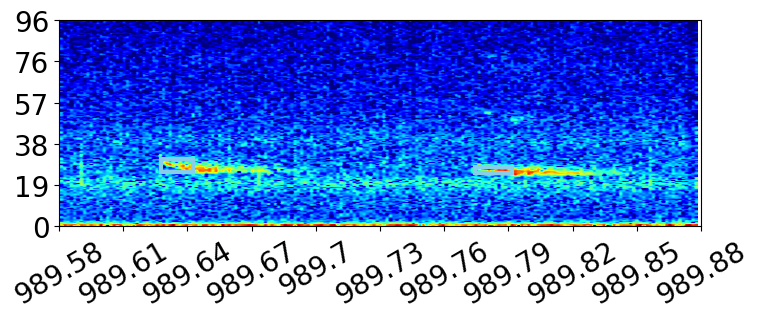

In [14]:
start = 989.58
duration = 0.3
plot_dets = location_df.loc[(pd.to_datetime(location_df['call_start_time'])>=file_dt_start)&(pd.to_datetime(location_df['call_end_time'])<=file_dt_end)]
plot_dets = plot_dets.loc[np.logical_and(plot_dets['start_time'] >= start, plot_dets['end_time'] <= (start+duration))]
audio_file.seek(int(fs*start))
audio_seg = audio_file.read(int(fs*duration))

spec_features = dict()
spec_features['vmax'] = 0 # hide anything above vmax dB
spec_features['vmin'] = -60 # hide anything below vmin dB
spec_features['NFFT'] = 512
spec_features['cmap'] = 'jet'

plt.figure(figsize=(8, 3.6))
plt.rcParams.update({'font.size': 20})
plt.specgram(audio_seg, NFFT=spec_features['NFFT'], cmap=spec_features['cmap'], vmin=spec_features['vmin'])
ax = plt.gca()
for i, row in plot_dets.iterrows():
    rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                    (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                    linewidth=3, edgecolor=FREQUENCY_COLOR_MAPPINGS[row['freq_group']], facecolor='none', alpha=1)

    ax.add_patch(rect)

plt.yticks(ticks=np.linspace(0, 1*(192000/fs), 6), labels=np.linspace(0, 192/2, 6).astype('int'))
plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), labels=np.linspace(start, start+duration, 11).round(2), color='k', rotation=30)
plt.ylabel("")
plt.xlabel("")
plt.ylim(0, 96/125)

plt.tight_layout()
plt.show()

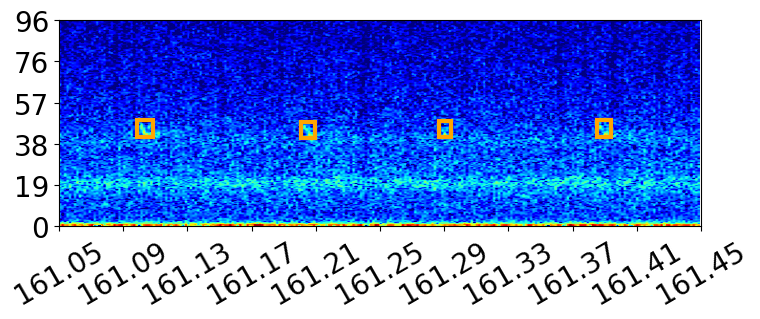

In [15]:
start = 161.05
duration = 0.4
plot_dets = location_df.loc[(pd.to_datetime(location_df['call_start_time'])>=file_dt_start)&(pd.to_datetime(location_df['call_end_time'])<=file_dt_end)]
plot_dets = plot_dets.loc[np.logical_and(plot_dets['start_time'] >= start, plot_dets['end_time'] <= (start+duration))]
audio_file.seek(int(fs*start))
audio_seg = audio_file.read(int(fs*duration))

spec_features = dict()
spec_features['vmax'] = 0 # hide anything above vmax dB
spec_features['vmin'] = -60 # hide anything below vmin dB
spec_features['NFFT'] = 512
spec_features['cmap'] = 'jet'

plt.figure(figsize=(8, 3.6))
plt.rcParams.update({'font.size': 20})
plt.specgram(audio_seg, NFFT=spec_features['NFFT'], cmap=spec_features['cmap'], vmin=spec_features['vmin'])
ax = plt.gca()
for i, row in plot_dets.iterrows():
    rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                    (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                    linewidth=3, edgecolor=FREQUENCY_COLOR_MAPPINGS[row['freq_group']], facecolor='none', alpha=1)
    ax.add_patch(rect)

plt.yticks(ticks=np.linspace(0, 1*(192000/fs), 6), labels=np.linspace(0, 192/2, 6).astype('int'))
plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), labels=np.linspace(start, start+duration, 11).round(2), color='k', rotation=30)
plt.ylabel("")
plt.xlabel("")
plt.ylim(0, 96/125)

plt.tight_layout()
plt.show()

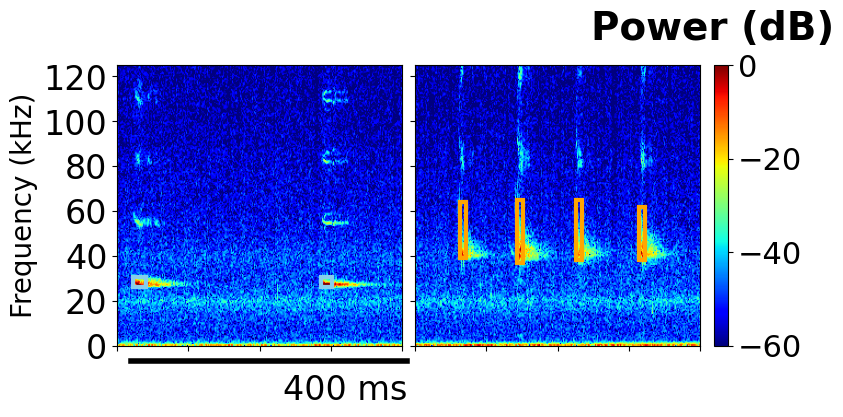

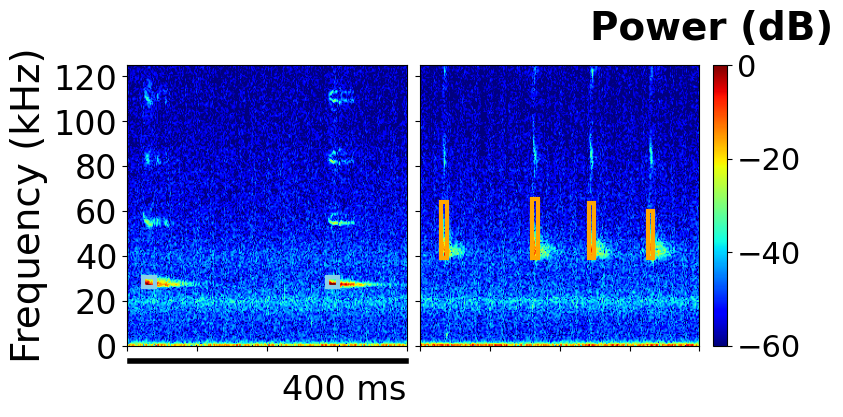

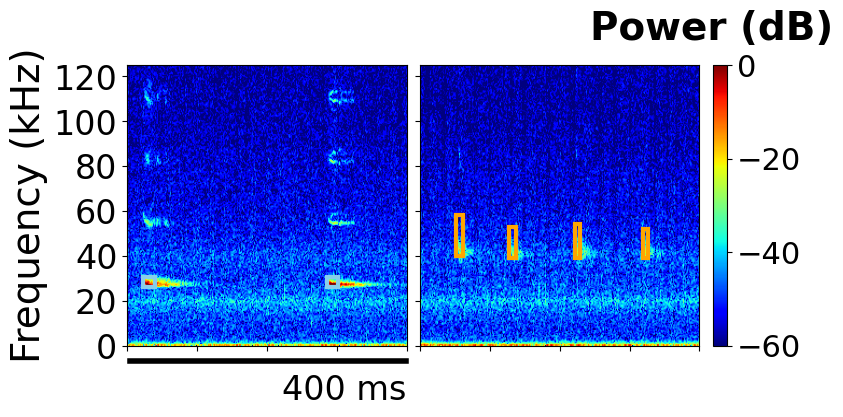

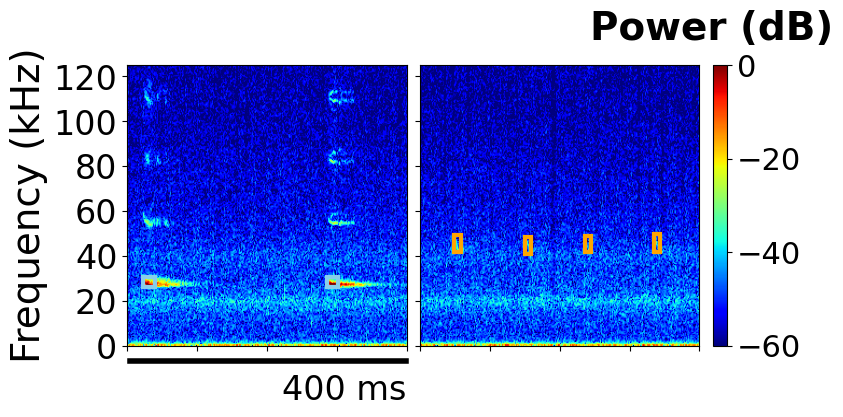

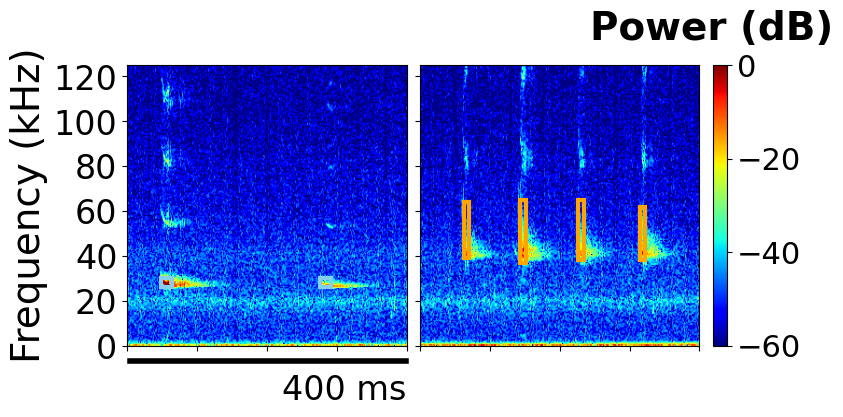

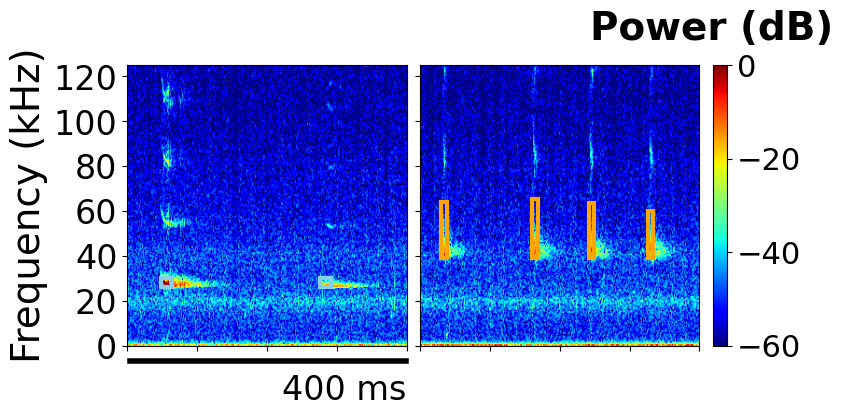

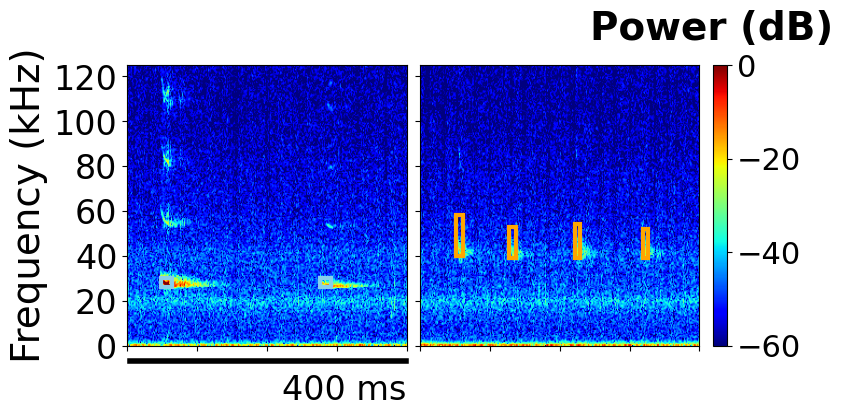

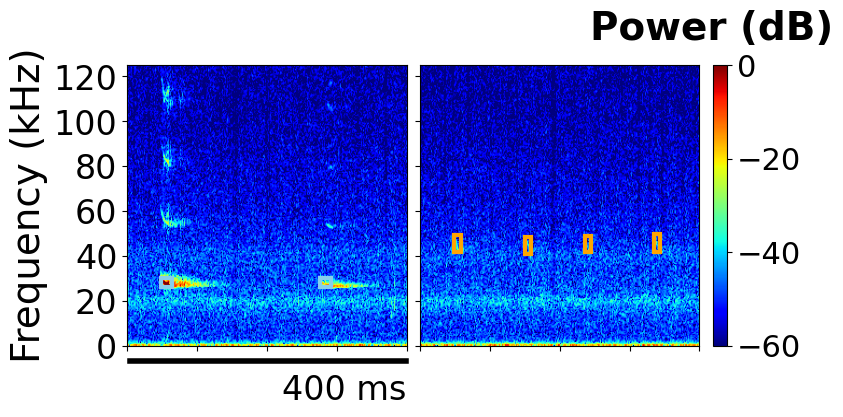

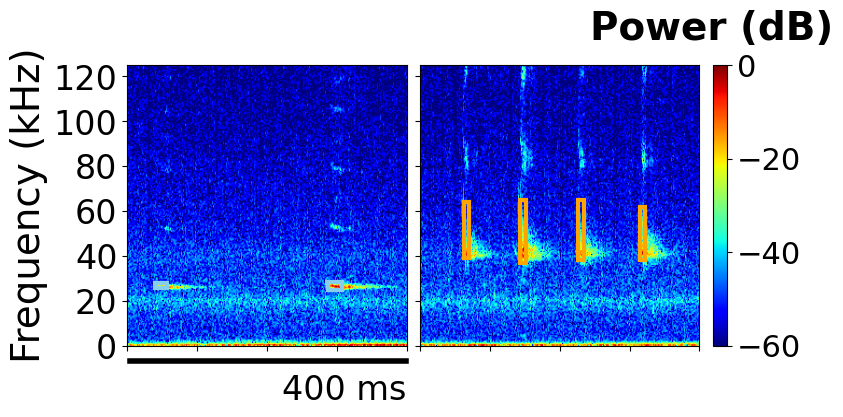

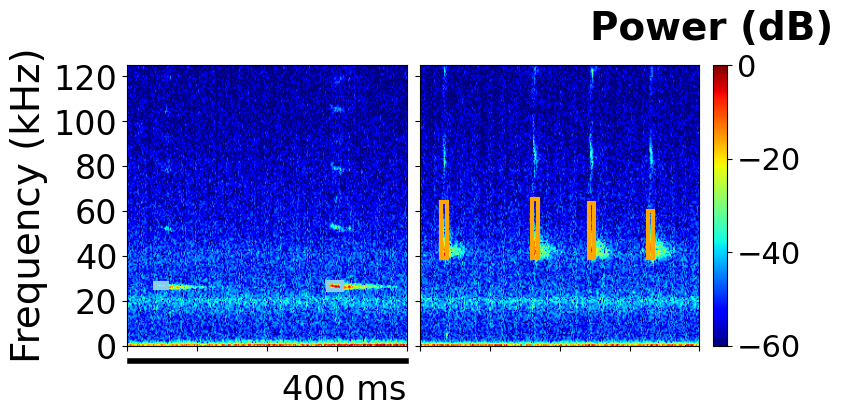

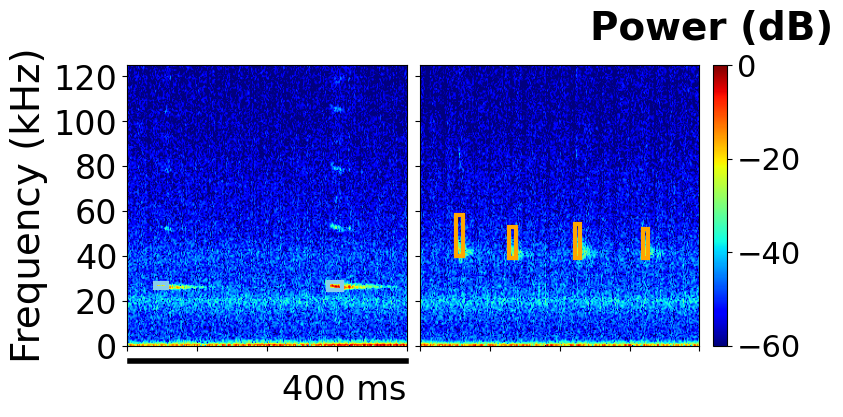

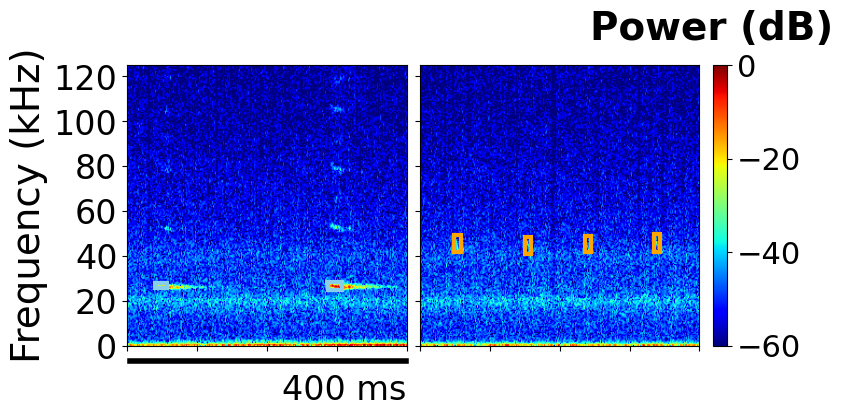

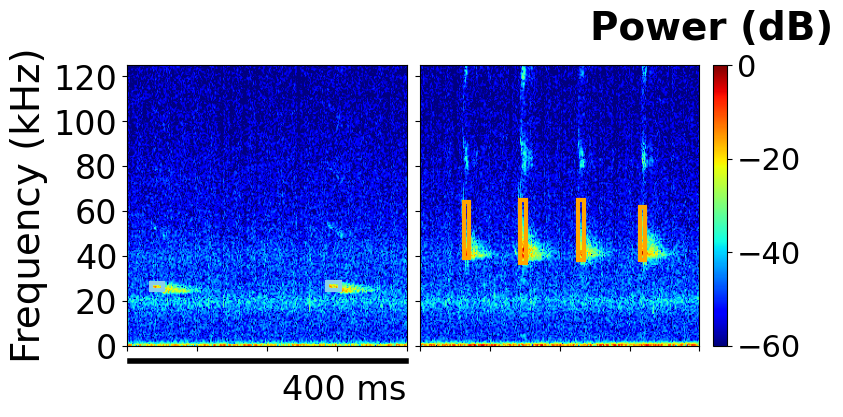

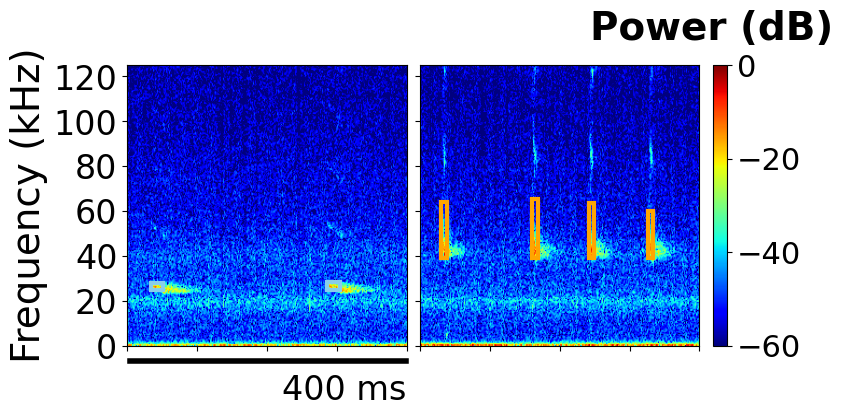

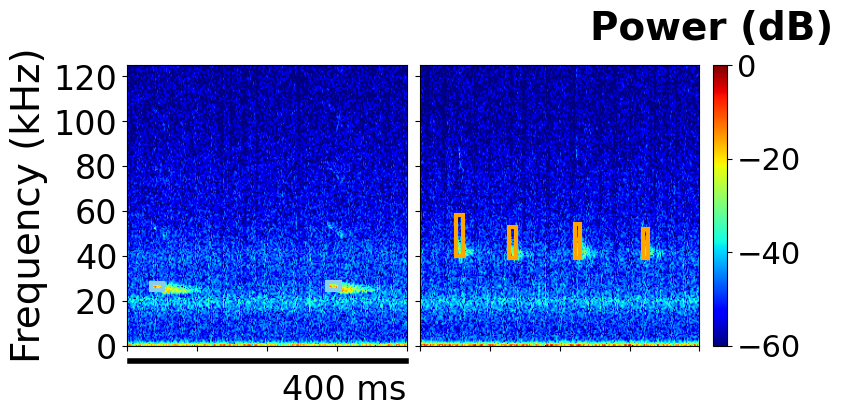

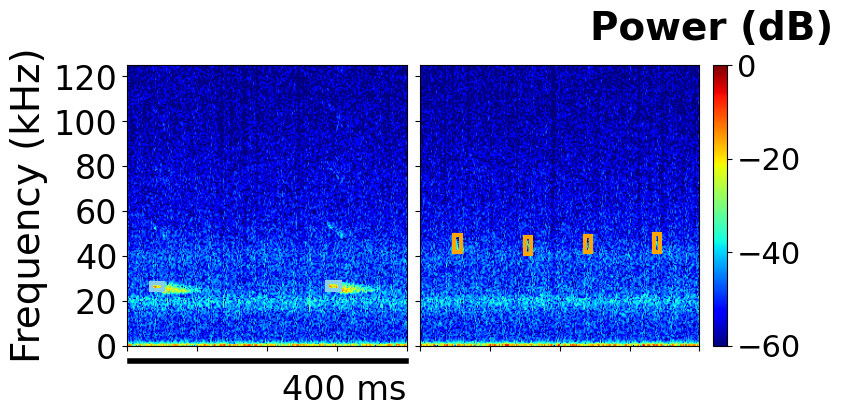

In [16]:
observed_LFs = [401.5, 402.52, 410.14, 989.74]
observed_HFs = [136.42, 140.38, 152.52, 161.05]
for observed_LF in observed_LFs:
    for observed_HF in observed_HFs:
        start_LF = observed_LF
        duration = 0.4
        plot_dets = location_df.loc[(pd.to_datetime(location_df['call_start_time'])>=file_dt_start)&(pd.to_datetime(location_df['call_end_time'])<=file_dt_end)]
        plot_dets_LF = plot_dets.loc[np.logical_and(plot_dets['start_time'] >= start_LF, plot_dets['end_time'] <= (start_LF+duration))]
        audio_file.seek(int(fs*start_LF))
        audio_seg_LF = audio_file.read(int(fs*duration))

        start_HF = observed_HF
        duration = 0.4
        plot_dets = location_df.loc[(pd.to_datetime(location_df['call_start_time'])>=file_dt_start)&(pd.to_datetime(location_df['call_end_time'])<=file_dt_end)]
        plot_dets_HF = plot_dets.loc[np.logical_and(plot_dets['start_time'] >= start_HF, plot_dets['end_time'] <= (start_HF+duration))]
        audio_file.seek(int(fs*start_HF))
        audio_seg_HF = audio_file.read(int(fs*duration))

        spec_features = dict()
        spec_features['vmax'] = 0 # hide anything above vmax dB
        spec_features['vmin'] = -60 # hide anything below vmin dB
        spec_features['NFFT'] = 512
        spec_features['cmap'] = 'jet'

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.2), constrained_layout=True, sharey=True)
        plt.rcParams.update({'font.size': 28})
        spec_LF = ax1.specgram(audio_seg_LF, NFFT=spec_features['NFFT'],
                            cmap=spec_features['cmap'], vmin=spec_features['vmin'], vmax=spec_features['vmax'])
        plot_det_bounds_in_ax(ax1, start_LF, MAX_FREQ_LIMIT, plot_dets_LF, linewidth=3, alpha=1)
        ax1.set_xticks(ticks=np.linspace(0, duration * MAX_FREQ_LIMIT, 5))
        x_labs = [''] * ax1.get_xticks().shape[0]
        ax1.set_xticklabels(x_labs, color='k')
        ax1.set_ylabel("Frequency (kHz)")

        spec_HF = ax2.specgram(audio_seg_HF, NFFT=spec_features['NFFT'],
                            cmap=spec_features['cmap'], vmin=spec_features['vmin'], vmax=spec_features['vmax'])
        plot_det_bounds_in_ax(ax2, start_HF, MAX_FREQ_LIMIT, plot_dets_HF, linewidth=3, alpha=1)
        ax2.set_xticks(ticks=np.linspace(0, duration * MAX_FREQ_LIMIT, 5))
        x_labs = [''] * ax1.get_xticks().shape[0]
        ax2.set_xticklabels(x_labs, color='k')

        y_labs = np.arange(0, MAX_FREQ_LIMIT/1000, 20).astype('int')
        ax1.set_yticks(ticks=y_labs / (MAX_FREQ_LIMIT/1000))
        ax1.set_yticklabels(y_labs, fontsize=plt.rcParams['font.size']-4)

        cbar = fig.colorbar(spec_HF[3], ax=ax2, orientation='vertical')
        cbar.ax.set_position([ax2.get_position().x1 + 0.02, ax2.get_position().y0, 0.02, ax2.get_position().height])
        cbar.ax.tick_params(labelsize=plt.rcParams['font.size']-6)
        fig.text(x=ax2.get_position().x1-0.1, y=ax2.get_position().y1 + 0.15, s='Power (dB)', fontweight='bold', fontsize=plt.rcParams['font.size'])
        cbar.ax.yaxis.set_ticks_position('right')  # Keep ticks on the right

        ax1_bbox = ax1.get_position(original=False)
        start_x = ax1_bbox.x0+0.0125
        width_x = ax1_bbox.width+0.0275
        line_ax = fig.add_axes([start_x, 0.0, width_x, 0.05])
        line_ax.plot([0, 1], [0.5, 0.5], color='black', lw=4)
        line_ax.axis('off')
        line_ax.text(1.0, 0.4, f"{int(duration*1000)} ms", ha='right', va='center', fontsize=plt.rcParams['font.size']-4)

        fig.savefig('FIG2BC_adityas_manuscript.png', bbox_inches='tight', dpi=600)
        plt.show()

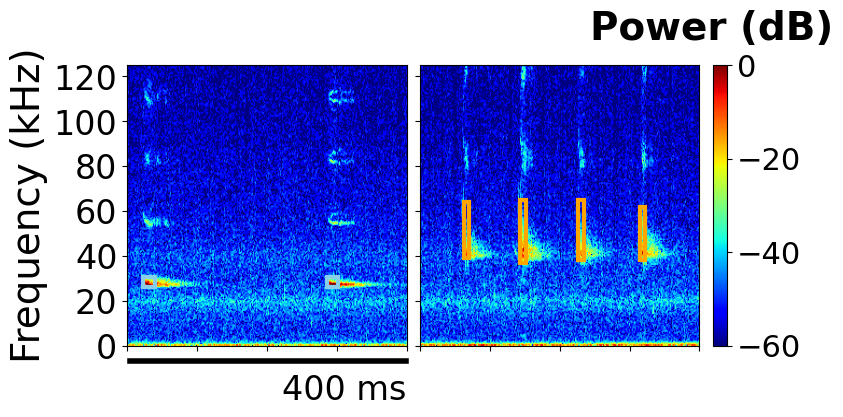

In [17]:
observed_LFs = [401.5]
observed_HFs = [136.42]
for observed_LF in observed_LFs:
    for observed_HF in observed_HFs:
        start_LF = observed_LF
        duration = 0.4
        plot_dets = location_df.loc[(pd.to_datetime(location_df['call_start_time'])>=file_dt_start)&(pd.to_datetime(location_df['call_end_time'])<=file_dt_end)]
        plot_dets_LF = plot_dets.loc[np.logical_and(plot_dets['start_time'] >= start_LF, plot_dets['end_time'] <= (start_LF+duration))]
        audio_file.seek(int(fs*start_LF))
        audio_seg_LF = audio_file.read(int(fs*duration))

        start_HF = observed_HF
        duration = 0.4
        plot_dets = location_df.loc[(pd.to_datetime(location_df['call_start_time'])>=file_dt_start)&(pd.to_datetime(location_df['call_end_time'])<=file_dt_end)]
        plot_dets_HF = plot_dets.loc[np.logical_and(plot_dets['start_time'] >= start_HF, plot_dets['end_time'] <= (start_HF+duration))]
        audio_file.seek(int(fs*start_HF))
        audio_seg_HF = audio_file.read(int(fs*duration))

        spec_features = dict()
        spec_features['vmax'] = 0 # hide anything above vmax dB
        spec_features['vmin'] = -60 # hide anything below vmin dB
        spec_features['NFFT'] = 512
        spec_features['cmap'] = 'jet'

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.2), constrained_layout=True, sharey=True)
        plt.rcParams.update({'font.size': 28})
        spec_LF = ax1.specgram(audio_seg_LF, NFFT=spec_features['NFFT'],
                            cmap=spec_features['cmap'], vmin=spec_features['vmin'], vmax=spec_features['vmax'])
        plot_det_bounds_in_ax(ax1, start_LF, MAX_FREQ_LIMIT, plot_dets_LF, linewidth=3, alpha=1)
        ax1.set_xticks(ticks=np.linspace(0, duration * MAX_FREQ_LIMIT, 5))
        x_labs = [''] * ax1.get_xticks().shape[0]
        ax1.set_xticklabels(x_labs, color='k')
        ax1.set_ylabel("Frequency (kHz)")

        spec_HF = ax2.specgram(audio_seg_HF, NFFT=spec_features['NFFT'],
                            cmap=spec_features['cmap'], vmin=spec_features['vmin'], vmax=spec_features['vmax'])
        plot_det_bounds_in_ax(ax2, start_HF, MAX_FREQ_LIMIT, plot_dets_HF, linewidth=3, alpha=1)
        ax2.set_xticks(ticks=np.linspace(0, duration * MAX_FREQ_LIMIT, 5))
        x_labs = [''] * ax1.get_xticks().shape[0]
        ax2.set_xticklabels(x_labs, color='k')

        y_labs = np.arange(0, MAX_FREQ_LIMIT/1000, 20).astype('int')
        ax1.set_yticks(ticks=y_labs / (MAX_FREQ_LIMIT/1000))
        ax1.set_yticklabels(y_labs, fontsize=plt.rcParams['font.size']-4)

        cbar = fig.colorbar(spec_HF[3], ax=ax2, orientation='vertical')
        cbar.ax.set_position([ax2.get_position().x1 + 0.02, ax2.get_position().y0, 0.02, ax2.get_position().height])
        cbar.ax.tick_params(labelsize=plt.rcParams['font.size']-6)
        fig.text(x=ax2.get_position().x1-0.1, y=ax2.get_position().y1 + 0.15, s='Power (dB)', fontweight='bold', fontsize=plt.rcParams['font.size'])
        cbar.ax.yaxis.set_ticks_position('right')  # Keep ticks on the right

        ax1_bbox = ax1.get_position(original=False)
        start_x = ax1_bbox.x0+0.0125
        width_x = ax1_bbox.width+0.0275
        line_ax = fig.add_axes([start_x, 0.0, width_x, 0.05])
        line_ax.plot([0, 1], [0.5, 0.5], color='black', lw=4)
        line_ax.axis('off')
        line_ax.text(1.0, 0.4, f"{int(duration*1000)} ms", ha='right', va='center', fontsize=plt.rcParams['font.size']-4)

        fig.savefig('FIG2BC_adityas_manuscript.png', bbox_inches='tight', dpi=600)
        plt.show()

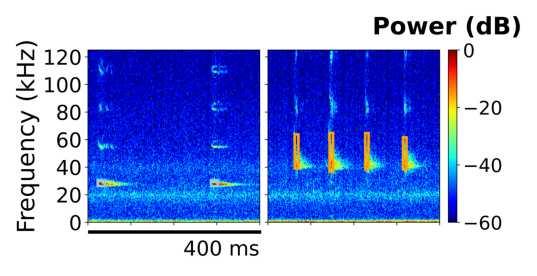

In [18]:
img = mpimg.imread("FIG2BC_adityas_manuscript.png")

fig, ax = plt.subplots(figsize=(7.2, 3.4))
ax.imshow(img)
ax.axis('off')
fig.tight_layout()
plt.show()

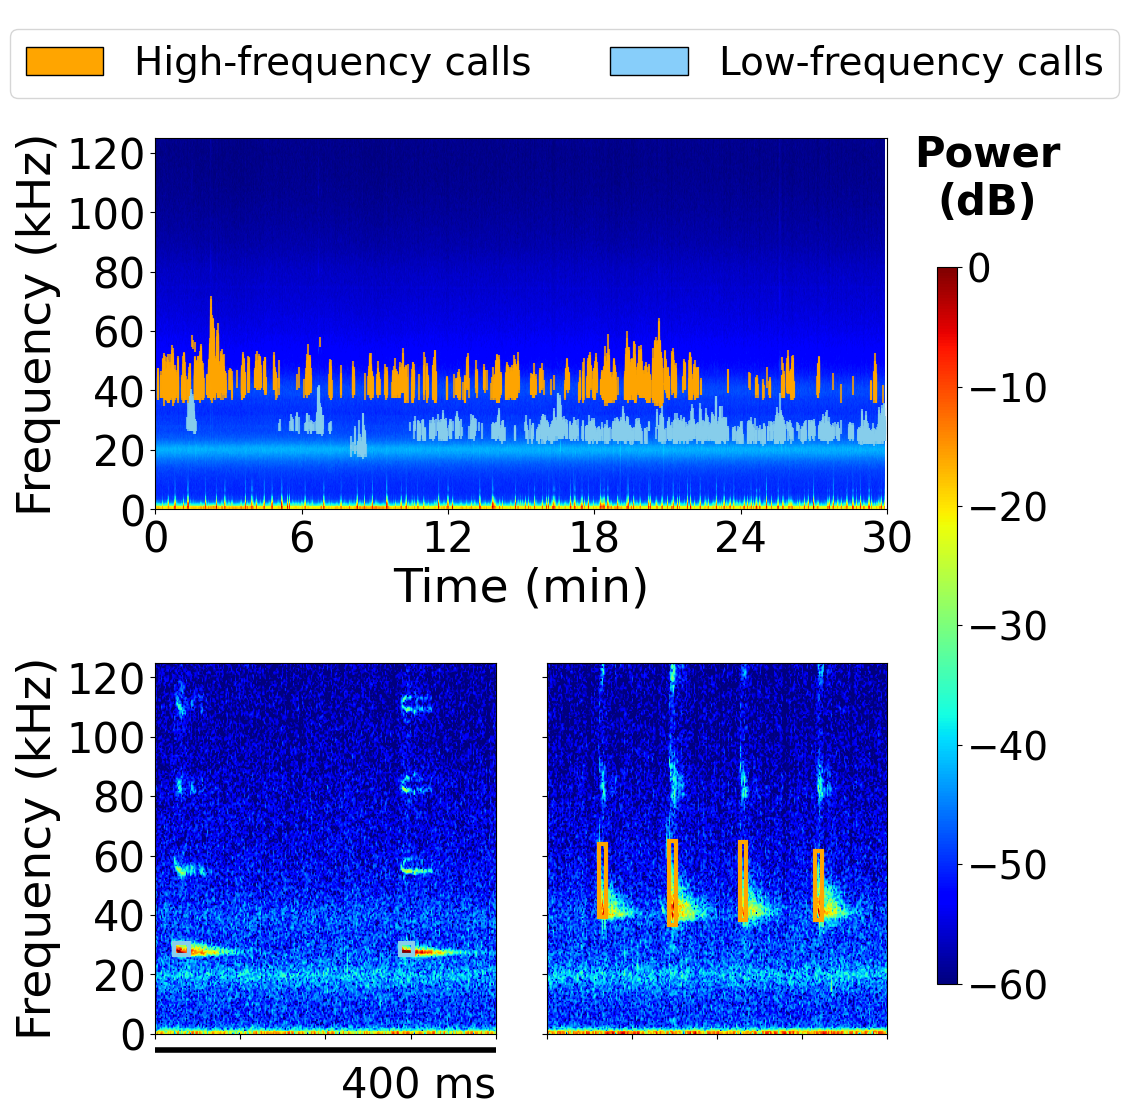

In [19]:
# Create a single figure with GridSpec
fig = plt.figure(figsize=(10, 10))
plt.rcParams.update({'font.size': 34})
gs = GridSpec(2, 2, height_ratios=[2, 2])

# Plot 1: The large top plot (First Figure)
ax_top = fig.add_subplot(gs[0, :])
fig, ax_top = plot_dets_over_audio_seg(fig, ax_top, audio_features, spec_features, plot_dets, data_params)
ax_top.set_ylabel("Frequency (kHz)")
ax_top.set_xlabel("Time (min)")
fig.tight_layout()

# Create legend patches
orange_patch = patches.Patch(facecolor='orange', edgecolor='k', label='High-frequency calls')
cyan_patch = patches.Patch(facecolor='lightskyblue', edgecolor='k', label='Low-frequency calls')
legend_patches = [orange_patch, cyan_patch]

legend_ax = fig.add_axes([0.1, 0.0, 1.0, 1.075])
legend_ax.axis('off')
legend_ax.legend(handles=legend_patches, fontsize=plt.rcParams['font.size']-6, ncol=2, loc='upper center')

# Plot 2: Left subplot of the second figure (Low-Frequency)
ax_left = fig.add_subplot(gs[1, 0])
spec_LF = ax_left.specgram(audio_seg_LF, NFFT=spec_features['NFFT'],
                           cmap=spec_features['cmap'], vmin=spec_features['vmin'], vmax=spec_features['vmax'])
plot_det_bounds_in_ax(ax_left, start_LF, MAX_FREQ_LIMIT, plot_dets_LF, linewidth=3, alpha=1)
ax_left.set_xticks(ticks=np.linspace(spec_LF[2][0], spec_LF[2][-1], 5))
ax_left.set_xlim(spec_LF[2][0], spec_LF[2][-1])
x_labs = [''] * ax_left.get_xticks().shape[0]
ax_left.set_xticklabels(x_labs, color='k')
ax_left.set_ylabel("Frequency (kHz)")
y_labs = np.arange(0, MAX_FREQ_LIMIT / 1000, 20).astype('int')
ax_left.set_yticks(ticks=y_labs / (MAX_FREQ_LIMIT / 1000))
ax_left.set_yticklabels(y_labs, fontsize=plt.rcParams['font.size']-4)

# Plot 3: Right subplot of the second figure (High-Frequency)
ax_right = fig.add_subplot(gs[1, 1])
spec_HF = ax_right.specgram(audio_seg_HF, NFFT=spec_features['NFFT'],
                            cmap=spec_features['cmap'], vmin=spec_features['vmin'], vmax=spec_features['vmax'])
plot_det_bounds_in_ax(ax_right, start_HF, MAX_FREQ_LIMIT, plot_dets_HF, linewidth=3, alpha=1)
ax_right.set_xticks(ticks=np.linspace(spec_HF[2][0], spec_HF[2][-1], 5))
ax_right.set_xlim(spec_HF[2][0], spec_HF[2][-1])
x_labs = [''] * ax_right.get_xticks().shape[0]
ax_right.set_xticklabels(x_labs, color='k')
ax_right.set_yticks(ticks=y_labs / (MAX_FREQ_LIMIT / 1000))
ax_right.set_yticklabels([''] * ax_right.get_yticks().shape[0])

# Add colorbar to the right of both subplots
pos1 = ax_top.get_position(original=False)
pos2 = ax_right.get_position(original=False)
colorbar_ax = fig.add_axes([pos2.x1 + 0.05, 0.05+pos2.y0, 0.02, 0.8*(pos1.y1 - pos2.y0)])
cbar = fig.colorbar(spec_HF[3], cax=colorbar_ax, orientation='vertical')
cbar.ax.tick_params(labelsize=plt.rcParams['font.size']-6)
fig.text(x=ax_top.get_position().x1+0.1, y=ax_top.get_position().y0+0.295, s='Power\n(dB)', ha='center', fontweight='bold', fontsize=plt.rcParams['font.size']-4)

# Add horizontal line below the bottom subplots
ax1_bbox = ax_left.get_position(original=False)
start_x = ax1_bbox.x0
width_x = ax1_bbox.width
line_ax = fig.add_axes([start_x, 0.025, width_x, 0.02])
line_ax.plot([0, 1], [0.5, 0.5], color='black', lw=4)
line_ax.set_xlim(0,1)
line_ax.axis('off')
line_ax.text(1.0, 0.4, f"{int(duration*1000)} ms", ha='right', va='center', fontsize=plt.rcParams['font.size']-4)

fig.savefig('FIG2ABC_adityas_manuscript.png', dpi=600, bbox_inches='tight', bbox_extra_artists=[legend_ax, line_ax, colorbar_ax])
plt.show()

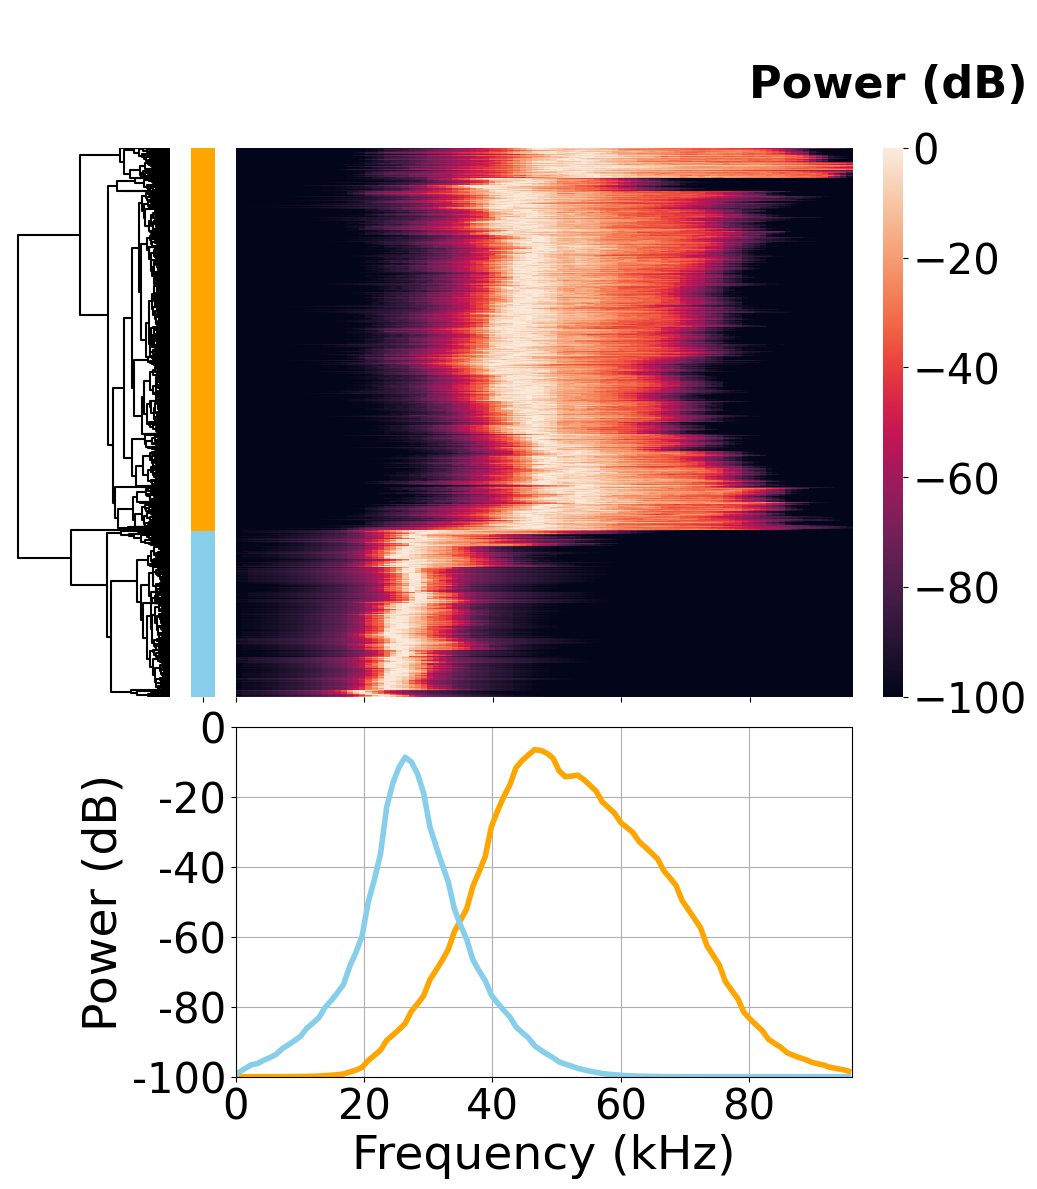

In [20]:
color_for_groups = {0: 'orange', 1: 'skyblue'}
label_for_groups = {0: 'High-frequency', 1: 'Low-frequency'}

site_key = 'all_locations'
output_dir = Path(f'../data/generated_welch/{site_key}')
if not output_dir.is_dir():
    output_dir.mkdir(parents=True)
output_file_type = 'top1_inbouts_welch_signals'

# Load data
welch_data = pd.read_csv(output_dir / f'2022_{site_key}_{output_file_type}.csv', index_col=0, low_memory=False)
welch_data.columns.name = 'Frequency (Hz)'
# welch_data = welch_data[:1000]

# Perform k-means clustering
k = 2
state = 1500
kmean_welch = KMeans(n_clusters=k, n_init=10, random_state=state).fit(welch_data)

# Create row colors for clustermap
groups = pd.Series(kmean_welch.labels_)
groups_to_labels = groups.map(label_for_groups)
groups_to_colors = groups.map(color_for_groups)

# Create the clustermap
g = sns.clustermap(
    welch_data,
    col_cluster=False,
    row_colors=groups_to_colors,
    cbar_pos=(1.0, 0.145, 0.02, 0.663),
    yticklabels=False,
    tree_kws=dict(linewidths=1.5, colors='k')
)

# Extract the figure and axes from sns.clustermap
fig = g.figure
heatmap_ax = g.ax_heatmap
dendro_ax = g.ax_row_dendrogram

# Adjust heatmap and dendrogram positions to align perfectly
heatmap_bbox = heatmap_ax.get_position(original=False)
dendro_bbox = dendro_ax.get_position(original=False)

# Reduce white space by directly setting the positions
heatmap_ax.set_position([heatmap_bbox.x0, heatmap_bbox.y0, heatmap_bbox.width, heatmap_bbox.height])
dendro_ax.set_position([dendro_bbox.x0, heatmap_bbox.y0, dendro_bbox.width, heatmap_bbox.height])

# Create a new subplot for the top plot (clustering centroids)
top_ax = fig.add_axes([heatmap_bbox.x0, heatmap_bbox.y0-0.38, heatmap_bbox.width-0.001, 0.35])

# Plot clustering centroids
plt.rcParams.update({'font.size': 34})
# top_ax.set_title(f'Centroid PSDs for Phonic Groups')
for i in range(k):
    top_ax.plot(kmean_welch.cluster_centers_[i], label=f'{label_for_groups[i]}',
                color=color_for_groups[i], alpha=1, linewidth=4)
xlabs = np.arange(0, 100, 20)
top_ax.set_xticks(xlabs*(100/96) - 0.5)
top_ax.set_xticklabels(xlabs, rotation=0, fontsize=plt.rcParams['font.size']-4)
top_ax.grid(which='both')
top_ax.set_xlabel('Frequency (kHz)')
top_ax.set_ylabel('Power (dB)')
top_ax.set_xlim(-0.5, 100-0.5)

top_ax.set_yticks(np.arange(0, 120, 20)*-1)
top_ax.set_yticklabels((np.arange(0, 120, 20)*-1).astype(int), rotation=0, fontsize=plt.rcParams['font.size']-4)
top_ax.set_ylim(-100, 0)

# Customize heatmap x-axis
heatmap_ax.set_xticks(xlabs*(100/96))
heatmap_ax.set_xticklabels(['']*heatmap_ax.get_xticks().shape[0], rotation=0)
heatmap_ax.set_ylabel('')
heatmap_ax.set_xlabel('')

# Adjust the colorbar position and labels
cbar = g.cax
cbar.set_position([heatmap_bbox.x1 + 0.03, heatmap_bbox.y0, 0.02, heatmap_bbox.height]) 
cbar.tick_params(labelsize=plt.rcParams['font.size']-4)
fig.text(x=heatmap_bbox.x1+0.175, y=heatmap_bbox.y1 + 0.05, s='Power (dB)', ha='right', fontweight='bold', fontsize=plt.rcParams['font.size']-2)

# Adjust the overall layout to prevent overlap
fig.savefig("FIG2DE_adityas_manuscript.png", dpi=600, bbox_inches="tight", bbox_extra_artists=[colorbar_ax])
plt.show()